In [2]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
import json
vector.register_awkward()

run2eeboostSR = "/data6/Users/achihwan/combine/CMSSW_14_1_0_pre4/src/HiggsAnalysis/CombinedLimit/data/HNWR/example/2018/root/2018_EE_Boosted_SR.root"
run2eeresolveSR = "/data6/Users/achihwan/combine/CMSSW_14_1_0_pre4/src/HiggsAnalysis/CombinedLimit/data/HNWR/example/2018/root/2018_EE_Resolved_SR.root"
run2muboostSR = "/data6/Users/achihwan/combine/CMSSW_14_1_0_pre4/src/HiggsAnalysis/CombinedLimit/data/HNWR/example/2018/root/2018_MuMu_Boosted_SR.root"
run2muresolveSR = "/data6/Users/achihwan/combine/CMSSW_14_1_0_pre4/src/HiggsAnalysis/CombinedLimit/data/HNWR/example/2018/root/2018_MuMu_Resolved_SR.root"

file1 = uproot.open(run2eeboostSR)
file2 = uproot.open(run2eeresolveSR)
file3 = uproot.open(run2muboostSR)
file4 = uproot.open(run2muresolveSR)





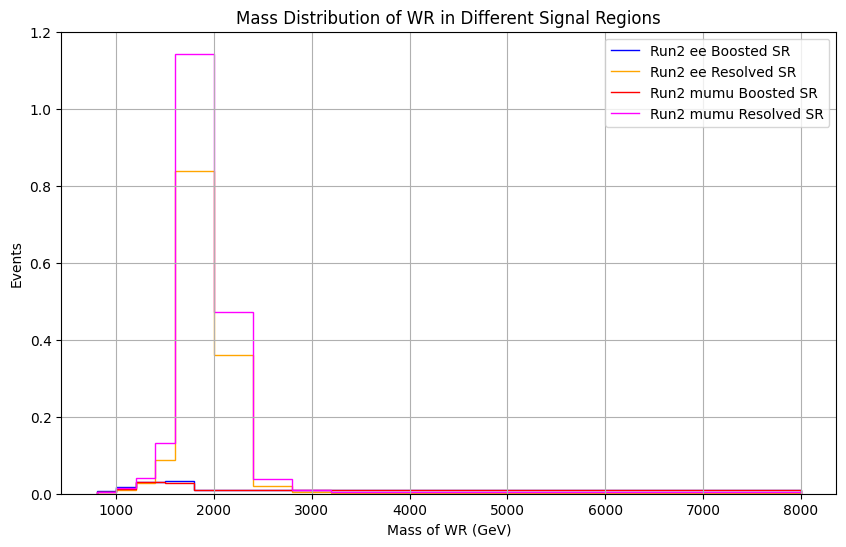

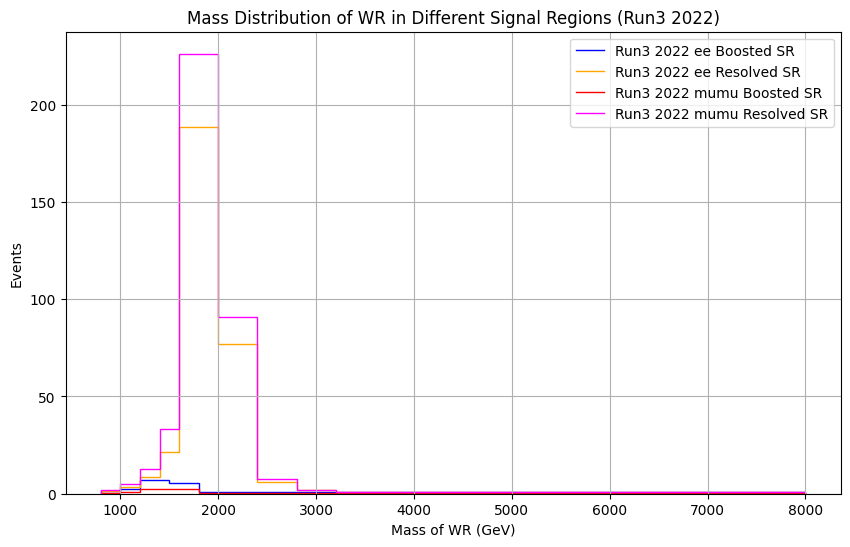

In [ ]:
### Run2
def get_hist(f, key):
    h = f[key]
    values = h.values()
    edges  = h.axis().edges()   # uproot. 안되면 h.to_numpy()
    return values, edges

v_eb, e_eb = get_hist(file1, "WR2000_N1000")
v_er, e_er = get_hist(file2, "WR2000_N1000")
v_mb, e_mb = get_hist(file3, "WR2000_N1000")
v_mr, e_mr = get_hist(file4, "WR2000_N1000")

plt.figure(figsize=(10,6))
plt.stairs(v_eb, e_eb, label='Run2 ee Boosted SR',    color='blue')
plt.stairs(v_er, e_er, label='Run2 ee Resolved SR',   color='orange')
plt.stairs(v_mb, e_mb, label='Run2 mumu Boosted SR',  color='red')
plt.stairs(v_mr, e_mr, label='Run2 mumu Resolved SR', color='magenta')
plt.xlabel('Mass of WR (GeV)')
plt.ylabel('Events')
plt.title('Mass Distribution of WR in Different Signal Regions')

plt.legend(); plt.grid(); plt.show()

### Run3 

def get_hist2(f, tree,key):
    h = f[tree][key]
    values = h.values()
    edges  = h.axis().edges()   # uproot. 안되면 h.to_numpy()
    return values, edges

run3_2022 = "/data6/Users/achihwan/combine/CMSSW_14_1_0_pre4/src/HiggsAnalysis/CombinedLimit/data/HNWR/from_youngwan/2022_shapes.root"
run3_2022EE = "/data6/Users/achihwan/combine/CMSSW_14_1_0_pre4/src/HiggsAnalysis/CombinedLimit/data/HNWR/from_youngwan/shapes_2022EE.root"
run3_2023 = "/data6/Users/achihwan/combine/CMSSW_14_1_0_pre4/src/HiggsAnalysis/CombinedLimit/data/HNWR/from_youngwan/shapes_2023.root"
run3_2023BPix = "/data6/Users/achihwan/combine/CMSSW_14_1_0_pre4/src/HiggsAnalysis/CombinedLimit/data/HNWR/from_youngwan/shapes_2023BPix.root"

r3_v_eb , r3_e_eb = get_hist2(uproot.open(run3_2022), "bEESR", "WR2000N1100EE")
r3_v_er , r3_e_er = get_hist2(uproot.open(run3_2022), "rEESR", "WR2000N1100EE")
r3_v_mb , r3_e_mb = get_hist2(uproot.open(run3_2022), "bMuMuSR", "WR2000N1100MM")
r3_v_mr , r3_e_mr = get_hist2(uproot.open(run3_2022), "rMuMuSR", "WR2000N1100MM")

plt.figure(figsize=(10,6))
plt.stairs(r3_v_eb, r3_e_eb, label='Run3 2022 ee Boosted SR',    color='blue')
plt.stairs(r3_v_er, r3_e_er, label='Run3 2022 ee Resolved SR',   color='orange')
plt.stairs(r3_v_mb, r3_e_mb, label='Run3 2022 mumu Boosted SR',  color='red')
plt.stairs(r3_v_mr, r3_e_mr, label='Run3 2022 mumu Resolved SR', color='magenta')
plt.xlabel('Mass of WR (GeV)')  
plt.ylabel('Events')
plt.title('Mass Distribution of WR in Different Signal Regions (Run3 2022)')

plt.legend(); plt.grid(); plt.show()





In [9]:
print(r3_v_eb/v_eb)
print(r3_v_er/v_er)
print(r3_v_mb/v_mb)
print(r3_v_mr/v_mr)

[270.29369748 149.87410357 219.08576936 161.75537264 110.87677114]
[367.26814268 355.6120684  322.48670648 244.94798286 225.23570467
 214.01198714 287.17421064 305.49927008 314.66624105]
[91.58433277 77.279214   82.84103685 86.61098781 61.99404486]
[417.43363289 310.1463288  312.09509985 253.76029756 197.92749624
 192.10292191 197.27024017 172.63993537 220.5793046 ]
